In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler


In [139]:
purf_pres1 = pd.read_csv('../../data/rawdata/1.csv')
purf_pres2 = pd.read_csv('../../data/rawdata/2.csv')
purf_pres3 = pd.read_csv('../../data/rawdata/3.csv')
purf_pres4 = pd.read_csv('../../data/rawdata/4.csv')
purf_pres = pd.read_csv('../../data/rawdata/6.csv')
purf_flow = pd.read_csv('../../data/rawdata/7.csv')


In [140]:
purf_pres1.columns = ['id','time', 'purf_pres','drop']
purf_pres2.columns = ['id','time', 'purf_pres','drop']
purf_pres3.columns = ['id','time', 'purf_pres','drop']
purf_pres4.columns = ['id','time', 'purf_pres','drop']
purf_pres.columns = ['id','time', 'purf_pres','drop']
purf_flow.columns = ['id', 'time', 'purf_flow', 'drop']


In [33]:
purf_prest = purf_pres1['purf_pres']+purf_pres2['purf_pres']+purf_pres3['purf_pres']+purf_pres4['purf_pres']
purf_prest.head()

0    21.770926
1    21.776407
2    21.767090
3    21.788696
4    21.771393
Name: purf_pres, dtype: float64

In [74]:
del purf_pres['id']
del purf_pres['drop']
del purf_flow['id']
del purf_flow['drop']

In [168]:
start = 1439 * 0
end = start + 1439 * 5
time = purf_flow[start:end]['time']
x = pd.to_datetime(time)

In [169]:

# 1. Calculate the difference between rows
purf_flow['smooth_flow'] = purf_flow['purf_flow'].rolling(window=5, center=True).median()
purf_flow['flow_diff'] = purf_flow['smooth_flow'].diff(periods=5)

# 2. Define a threshold for a "Pump Event" 
# (e.g., if flow jumps by more than 40 units in one step)
threshold = 40

purf_flow['pump_event'] = 0
purf_flow.loc[purf_flow['flow_diff'] > threshold, 'pump_event'] = 1  # Pump started
purf_flow.loc[purf_flow['flow_diff'] < -threshold, 'pump_event'] = -1 # Pump stopped

# 3. Use a rolling median to define "Plateaus" and filter out noise


# 4. Simple clustering/binning to assign Pump Count
# You can adjust these bins based on your specific flow peaks

bins = [0, 700, 800, 900, 1100] # Example boundaries for 2, 3, and 4 pumps
labels = [1, 2, 3, 4]
purf_flow['est_pumps_running'] = pd.cut(purf_flow['smooth_flow'], bins=bins, labels=labels)

pump = purf_flow[start:end]['est_pumps_running']
pump_change = purf_flow[start:end]['pump_event']

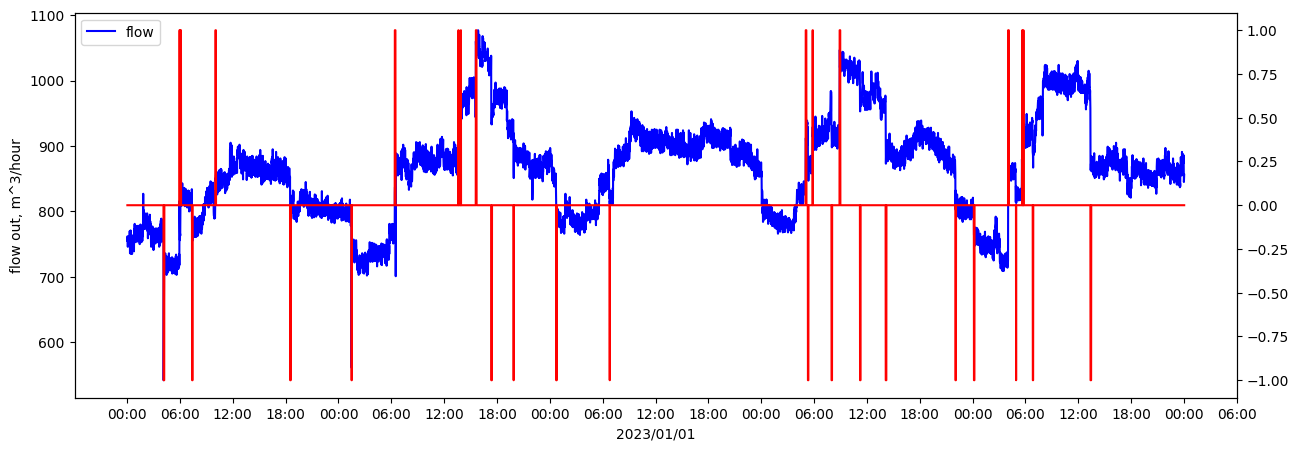

In [174]:
#flow
fig, ax1 = plt.subplots(figsize=(15,5))
y = purf_flow[start:end]['purf_flow']
ax1.plot(x, y, label='flow', color='blue')

#pressure total
#ax2 = ax1.twinx()
#z = purf_prest[start:end]#['purf_pres']
#ax2.plot(x, z, label='pres sum', color='red')
#ax2.set_ylabel('pres out, m^2/N')
#ax2.legend(loc='upper right')
#ax2.set_ylim(20,40)

#pressure
#ax3 = ax1.twinx()
#w = purf_pres[start:end]['purf_pres']
#ax3.plot(x,w,label='pres main', color='orange')
#ax3.set_ylim(8,10)
#ax3.legend(loc='lower right')

#estimated pump
#ax4 = ax1.twinx()
#ax4.plot(x,pump)
#ax4.set_ylim(0,4.1)

#pump change
ax5 = ax1.twinx()
ax5.plot(x,pump_change, color='red')

#=========misc config
#=========misc config
#=========misc config
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.set_xlabel('2023/01/01')
ax1.set_ylabel('flow out, m^3/hour')
ax1.legend(loc='upper left')


plt.xticks(rotation=45)

plt.show()

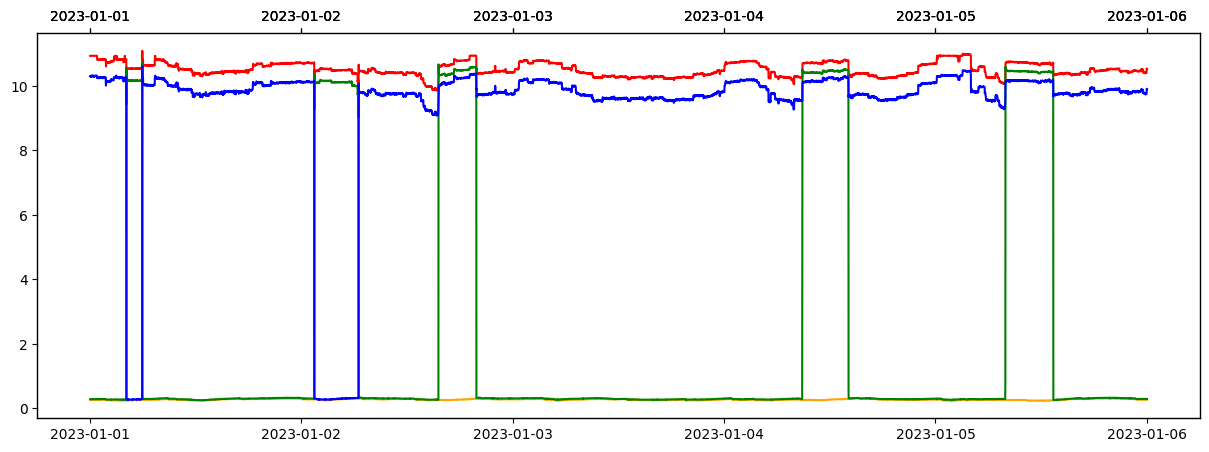

In [ ]:
fig, axp1 = plt.subplots(figsize=(15,5))
axp2, axp3, axp4 = axp1.twiny(),axp1.twiny(),axp1.twiny()

axp1.plot(x, purf_pres1['purf_pres'][start:end], label='pres1', color='red') #메인1
axp2.plot(x, purf_pres2['purf_pres'][start:end], label='pres2', color='orange') #거의 안돌리는
axp3.plot(x, purf_pres3['purf_pres'][start:end], label='pres3', color='green') #간혹 돌리는
axp4.plot(x, purf_pres4['purf_pres'][start:end], label='pres4', color='blue') #메인2

plt.show()